# CMAPSS Turbofan RUL Prediction
XGBoost with conditions-normalised sensors, rolling statistics, and SHAP explainability.

In [70]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

try:
    from pyprojroot import here

    DATA_DIR = here() / "data" / "raw"
except Exception:
    DATA_DIR = Path("data/raw")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
SEED = 42
RUL_CAP = 125
WINDOWS = [5, 15]

warnings.filterwarnings("ignore")

## 1. Load Dataset

In [71]:
COLS = ["unit", "cycle", "os1", "os2", "os3"] + [f"s{i}" for i in range(1, 22)]
DROP_SENSORS = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]  # near-zero variance
SCOLS = [c for c in COLS if c.startswith("s") and c not in DROP_SENSORS]


def load_fd(fd, split):
    df = pd.read_csv(
        DATA_DIR / f"{split}_FD00{fd}.txt", sep=r"\s+", header=None
    ).dropna(axis=1)
    df.columns = COLS
    df["fd"] = fd
    df["unit_global"] = str(fd) + "_" + df["unit"].astype(str)
    return df


train_raw = pd.concat([load_fd(i, "train") for i in range(1, 5)], ignore_index=True)
test_raw = pd.concat([load_fd(i, "test") for i in range(1, 5)], ignore_index=True)

rul_parts = []
for i in range(1, 5):
    r = pd.read_csv(DATA_DIR / f"RUL_FD00{i}.txt", header=None, names=["true_rul"])
    r["fd"] = i
    r["unit"] = range(1, len(r) + 1)
    r["unit_global"] = str(i) + "_" + r["unit"].astype(str)
    rul_parts.append(r)
rul_df = pd.concat(rul_parts, ignore_index=True)

print(f"Train: {len(train_raw):,} rows | {train_raw.unit_global.nunique()} engines")
print(f"Test:  {len(test_raw):,} rows  | {test_raw.unit_global.nunique()} engines")

Train: 160,359 rows | 709 engines
Test:  104,897 rows  | 707 engines


In [72]:
print(train_raw.columns)

Index(['unit', 'cycle', 'os1', 'os2', 'os3', 's1', 's2', 's3', 's4', 's5',
       's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16',
       's17', 's18', 's19', 's20', 's21', 'fd', 'unit_global'],
      dtype='object')


- unit = id of engine in FD (FD = data files)
- FD = type of dataset
- unit_global = unique value consist of "{FD}_{unit}", representing specific engine in specific FD

## 2. Feature Engineering

In [73]:
# conditions clustering
## FD001/FD003 = 1 condition
## FD002/FD004 = 6 conditions. k=6 handles both.
km = KMeans(n_clusters=6, random_state=SEED, n_init=10)
km.fit(train_raw[["os1", "os2", "os3"]])
train_raw["conditions"] = km.predict(train_raw[["os1", "os2", "os3"]])
test_raw["conditions"] = km.predict(test_raw[["os1", "os2", "os3"]])

# conditions-wise z-score normalisation (fit on train only)
rs = train_raw.groupby("conditions")[SCOLS].agg(["mean", "std"])
rs.columns = ["_".join(c) for c in rs.columns]


def conditions_norm(df):
    df = df.copy()
    for s in SCOLS:
        mu = df["conditions"].map(rs[f"{s}_mean"])
        sig = df["conditions"].map(rs[f"{s}_std"]).replace(0, 1e-6)
        df[s] = (df[s] - mu) / sig
    return df


train_n = conditions_norm(train_raw)
test_n = conditions_norm(test_raw)

- `train_n` and `test_n` has normalised sensors. Each normalisation happen within their own condition determined by kmeans in `os1,os1,os3`
- `conditions` categorical feature consist of `0,1,2,3,4,5` (total 6 conditions)

In [74]:
# RUL target for train
mc = train_n.groupby("unit_global")["cycle"].transform(
    "max"
)  # max cycle count before engine broke (in train set)
train_n["rul"] = (mc - train_n["cycle"]).clip(
    upper=RUL_CAP
)  # calculate RUL (countdown before engine broke, RUL=0 => engine broke)

# RUL target for test
te_life = test_n.groupby("unit_global")["cycle"].max().reset_index()
te_life.columns = ["unit_global", "last_obs"]
te_life = te_life.merge(rul_df[["unit_global", "true_rul"]], on="unit_global")
te_life["total_life"] = te_life["last_obs"] + te_life["true_rul"]
test_n = test_n.merge(te_life[["unit_global", "total_life"]], on="unit_global")

In [75]:
# # cycle fraction (train)
# train_n["cyc_frac"] = (
#     train_n["cycle"] / mc
# )  # cycle fraction: how far along the engine is in its life (0 at start, 1 at end)

# # Cycle fraction (test): true total life = last_obs + true_rul
# test_n["cyc_frac"] = test_n["cycle"] / test_n["total_life"]

In [76]:
# Rolling mean & std per engine
def add_rolling(df):
    df = df.sort_values(["unit_global", "cycle"]).copy()
    grp = df.groupby("unit_global")[SCOLS]
    for w in WINDOWS:
        rm = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
        rsd = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        rm.columns = [f"{c}_rm{w}" for c in SCOLS]
        rsd.columns = [f"{c}_rs{w}" for c in SCOLS]
        df = pd.concat([df, rm, rsd], axis=1)
    return df


print("Adding rolling features...")
train_f = add_rolling(train_n)
test_f = add_rolling(test_n)

FCOLS = (
    SCOLS
    + [f"{c}_rm{w}" for c in SCOLS for w in WINDOWS]
    + [f"{c}_rs{w}" for c in SCOLS for w in WINDOWS]
    + ["conditions"]
    # + ["cyc_frac"]
)
print(f"Feature count: {len(FCOLS)} | Train rows: {len(train_f):,}")

Adding rolling features...
Feature count: 71 | Train rows: 160,359


## 3. Train, Validation Split
Split on engine-level with ratio 80:20

In [77]:
np.random.seed(SEED)
all_eng = train_f["unit_global"].unique()
tr_eng = set(np.random.choice(all_eng, int(len(all_eng) * 0.8), replace=False))
va_eng = set(all_eng) - tr_eng

tr_data = train_f[train_f["unit_global"].isin(tr_eng)]
va_data = train_f[train_f["unit_global"].isin(va_eng)]

X_tr, y_tr = tr_data[FCOLS], tr_data["rul"]
X_va_es, y_va_es = va_data[FCOLS], va_data["rul"]  # all cycles, for early stopping

# val evaluation: random truncation per engine (mirrors test protocol)
va_rows = []
for eng, g in va_data.groupby("unit_global"):
    g = g.sort_values("cycle")
    cut = np.random.randint(max(1, len(g) // 4), len(g))
    va_rows.append(g.iloc[cut - 1])
va_trunc = pd.DataFrame(va_rows)
X_va, y_va = va_trunc[FCOLS], va_trunc["rul"]

# test: last observed cycle per engine
te_last = test_f.sort_values("cycle").groupby("unit_global").last().reset_index()
te_last = te_last.merge(rul_df[["unit_global", "true_rul"]], on="unit_global")
te_last["rul_capped"] = te_last["true_rul"].clip(upper=RUL_CAP)
X_te, y_te = te_last[FCOLS], te_last["rul_capped"]

print(
    f"Train rows: {len(X_tr):,} | Val engines: {len(X_va)} | Test engines: {len(X_te)}"
)

Train rows: 127,332 | Val engines: 142 | Test engines: 707


## 4. Train XGBoost

In [79]:
model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=50,
)

model.fit(X_tr, y_tr, eval_set=[(X_va_es, y_va_es)], verbose=200)
print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:40.43168
[200]	validation_0-rmse:17.53809
[400]	validation_0-rmse:17.24893
[600]	validation_0-rmse:17.11731
[800]	validation_0-rmse:17.06169
[1000]	validation_0-rmse:17.02030
[1200]	validation_0-rmse:17.00127
[1393]	validation_0-rmse:16.99007

Best iteration: 1343


## 5. Evaluation

In [91]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
    print(f"{name:40s}:  RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}  NASA={score:.0f}")
    return dict(
        rmse=rmse, mae=mae, r2=r2, score=score, pred=y_pred, true=np.array(y_true)
    )


res_va = evaluate("Validation (truncated)", y_va.values, model.predict(X_va))
res_te = evaluate("Test", y_te.values, model.predict(X_te))

print()
te_last["pred"] = model.predict(X_te)
for fd in range(1, 5):
    sub = te_last[te_last["unit_global"].str.startswith(str(fd))]
    r = np.sqrt(mean_squared_error(sub["rul_capped"], sub["pred"]))
    print(f"FD00{fd}:  RMSE={r:.2f}  n={len(sub)}")

Validation (truncated)                  :  RMSE=18.25  MAE=14.03  R2=0.802  NASA=1110
Test                                    :  RMSE=17.35  MAE=12.52  R2=0.830  NASA=6861

FD001:  RMSE=17.04  n=100
FD002:  RMSE=15.60  n=259
FD003:  RMSE=18.53  n=100
FD004:  RMSE=18.67  n=248


## 6. Sensor Plots

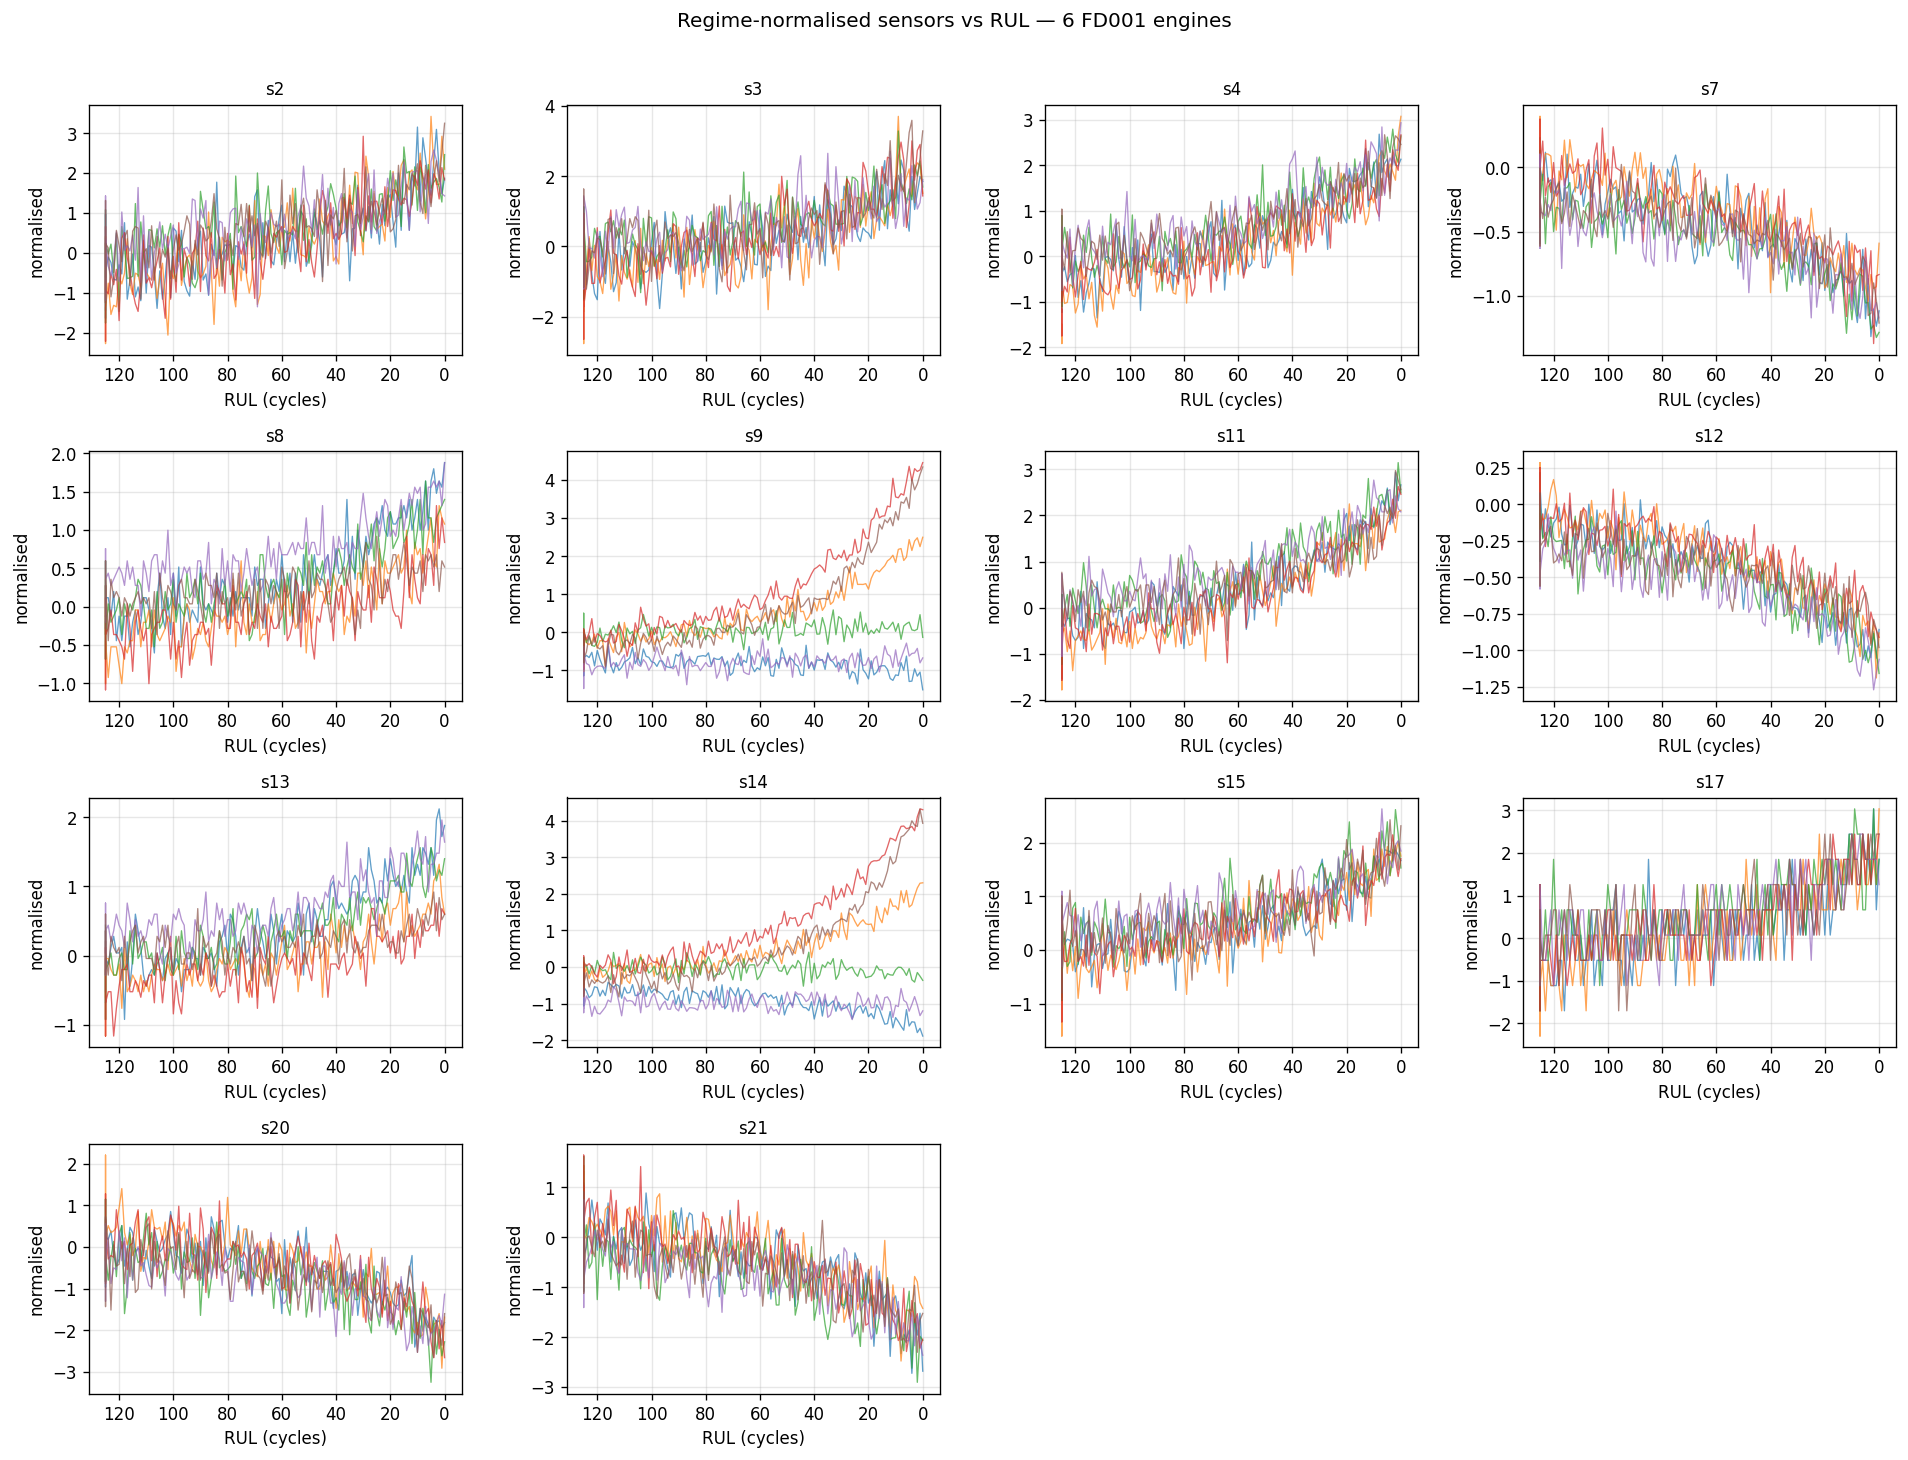

In [ ]:
sample_eng = train_f[train_f["fd"] == 1]["unit_global"].unique()[:6]
sdf = train_f[train_f["unit_global"].isin(sample_eng)].copy()

ncols = 4
nrows = int(np.ceil(len(SCOLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for ax, sensor in zip(axes, SCOLS):
    for eng in sample_eng:
        edf = sdf[sdf["unit_global"] == eng].sort_values("rul", ascending=False)
        ax.plot(edf["rul"], edf[sensor], lw=0.8, alpha=0.7)
    ax.invert_xaxis()
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel("RUL (cycles)")
    ax.set_ylabel("normalised")
    ax.grid(alpha=0.3)

for ax in axes[len(SCOLS) :]:
    ax.set_visible(False)

fig.suptitle("Conditions-normalised sensors vs RUL — 6 FD001 engines", y=1.01)
plt.tight_layout()
plt.savefig("sensor_vs_rul.png", bbox_inches="tight")
plt.show()

## 7. Engineered Feature Plots

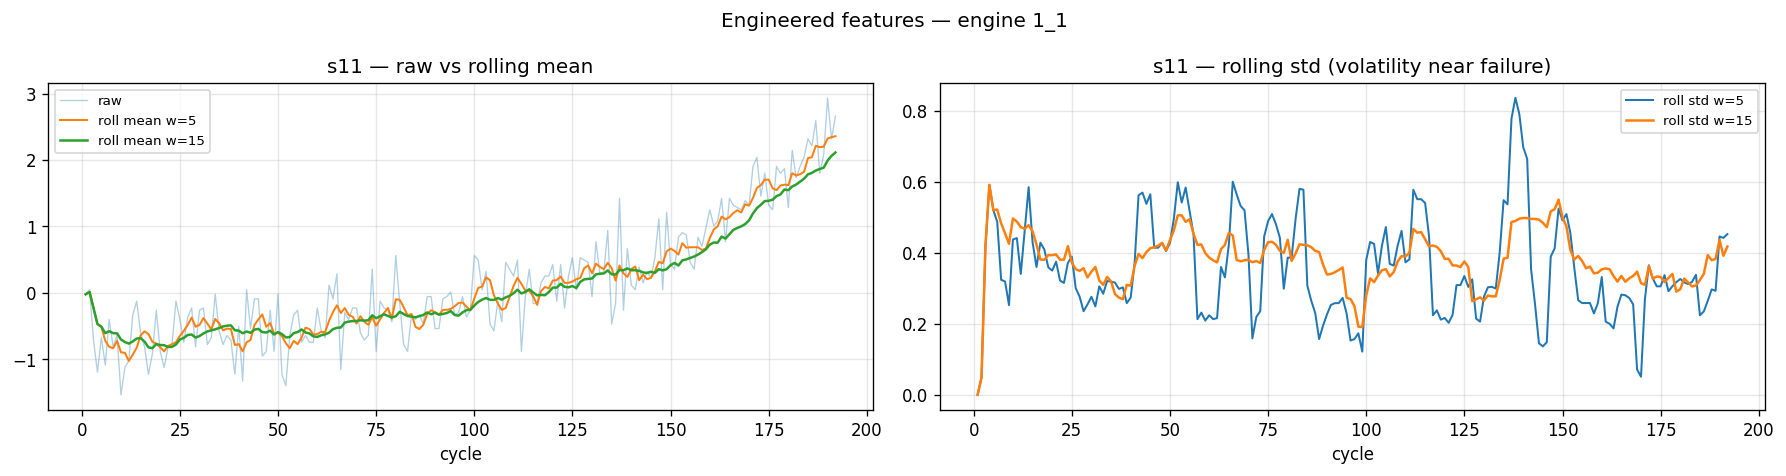

In [94]:
eng = sample_eng[0]
edf = train_f[train_f["unit_global"] == eng].sort_values("cycle")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ax = axes[0]
ax.plot(edf["cycle"], edf["s11"], alpha=0.35, lw=0.8, label="raw")
ax.plot(edf["cycle"], edf["s11_rm5"], lw=1.2, label="roll mean w=5")
ax.plot(edf["cycle"], edf["s11_rm15"], lw=1.5, label="roll mean w=15")
ax.set_title("s11 — raw vs rolling mean")
ax.set_xlabel("cycle")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(edf["cycle"], edf["s11_rs5"], lw=1.2, label="roll std w=5")
ax.plot(edf["cycle"], edf["s11_rs15"], lw=1.5, label="roll std w=15")
ax.set_title("s11 — rolling std (volatility near failure)")
ax.set_xlabel("cycle")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ax = axes[2]
# sc = ax.scatter(
#     edf["cyc_frac"], edf["s11"], s=6, alpha=0.5, c=edf["cycle"], cmap="plasma"
# )
# plt.colorbar(sc, ax=ax, label="cycle")
# ax.set_title("cycle fraction vs s11")
# ax.set_xlabel("cyc_frac  (0=start → 1=failure)")
# ax.grid(alpha=0.3)

fig.suptitle(f"Engineered features — engine {eng}")
plt.tight_layout()
plt.savefig("engineered_features.png", bbox_inches="tight")
plt.show()

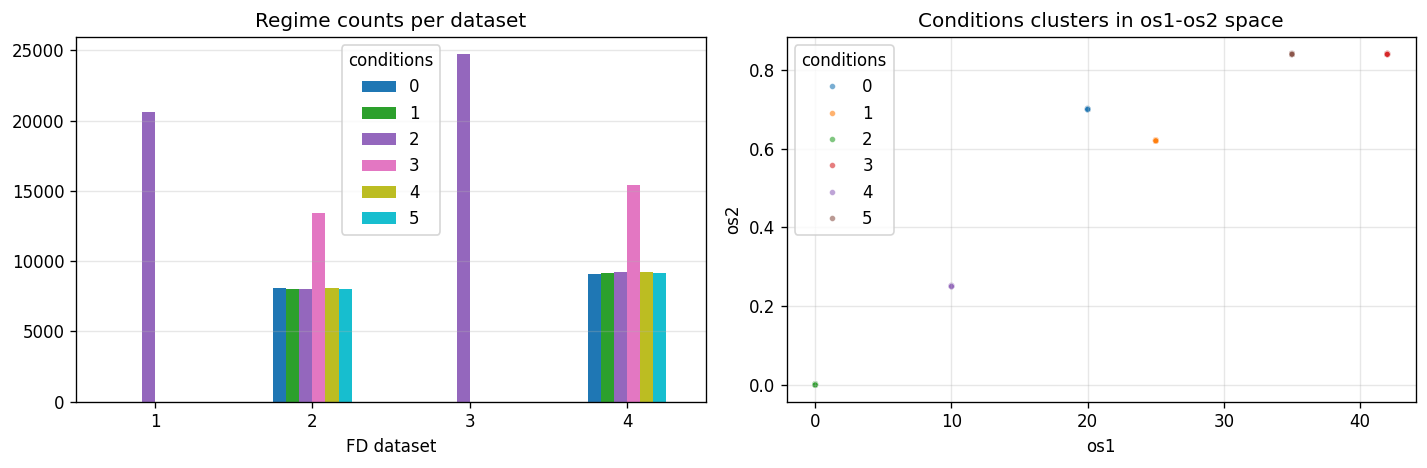

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_raw.groupby(["fd", "conditions"]).size().unstack().fillna(0).plot(
    kind="bar", ax=axes[0], colormap="tab10"
)
axes[0].set_title("Regime counts per dataset")
axes[0].set_xlabel("FD dataset")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

sns.scatterplot(
    data=train_raw.sample(4000, random_state=SEED),
    x="os1",
    y="os2",
    hue="conditions",
    palette="tab10",
    s=12,
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("Conditions clusters in os1-os2 space")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("conditions_clusters.png", bbox_inches="tight")
plt.show()

## 8. Prediction Plots

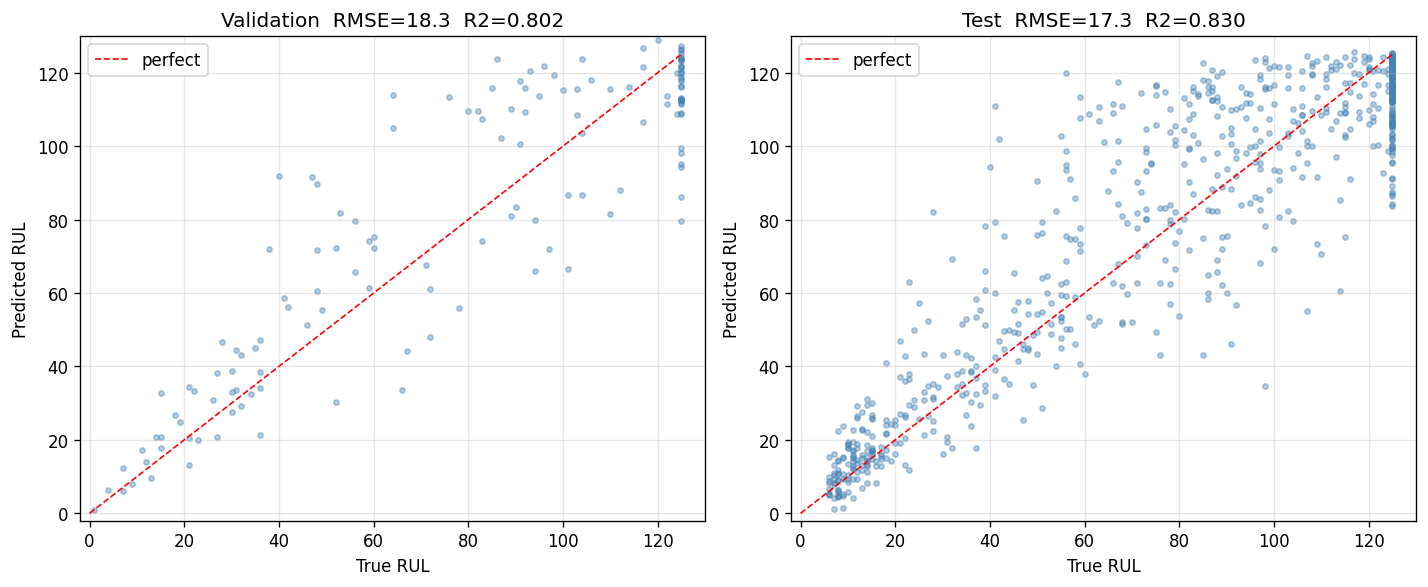

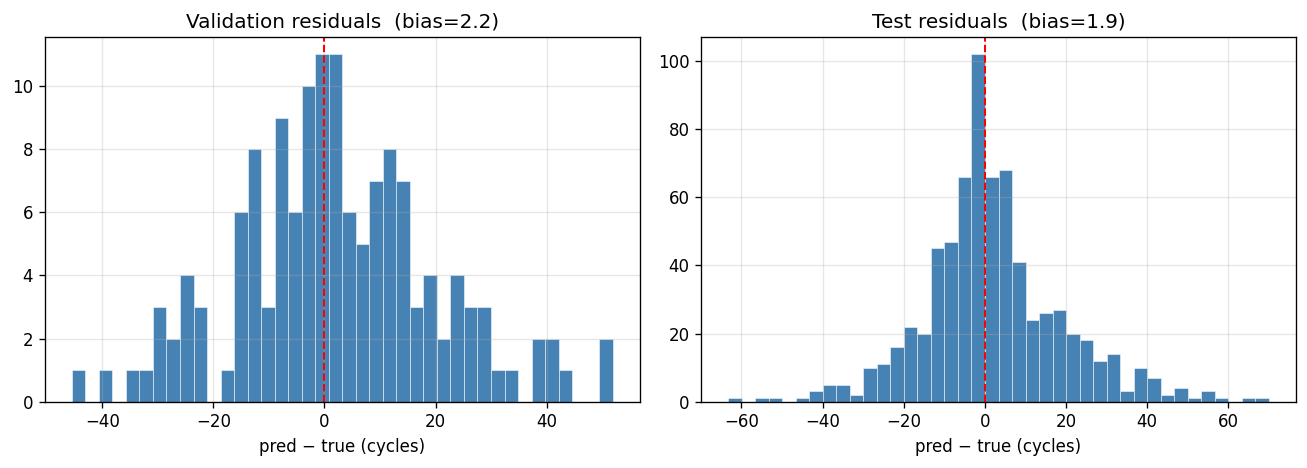

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, name in zip(axes, [res_va, res_te], ["Validation", "Test"]):
    ax.scatter(res["true"], res["pred"], s=10, alpha=0.4, color="steelblue")
    ax.plot([0, RUL_CAP], [0, RUL_CAP], "r--", lw=1, label="perfect")
    ax.set_xlim(-2, RUL_CAP + 5)
    ax.set_ylim(-2, RUL_CAP + 5)
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{name}  RMSE={res['rmse']:.1f}  R2={res['r2']:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pred_vs_true.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, name in zip(axes, [res_va, res_te], ["Validation", "Test"]):
    resid = res["pred"] - res["true"]
    ax.hist(resid, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red", lw=1.2, ls="--")
    ax.set_title(f"{name} residuals  (bias={resid.mean():.1f})")
    ax.set_xlabel("pred − true (cycles)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("residuals.png", bbox_inches="tight")
plt.show()

## 9. Feature Importance & SHAP

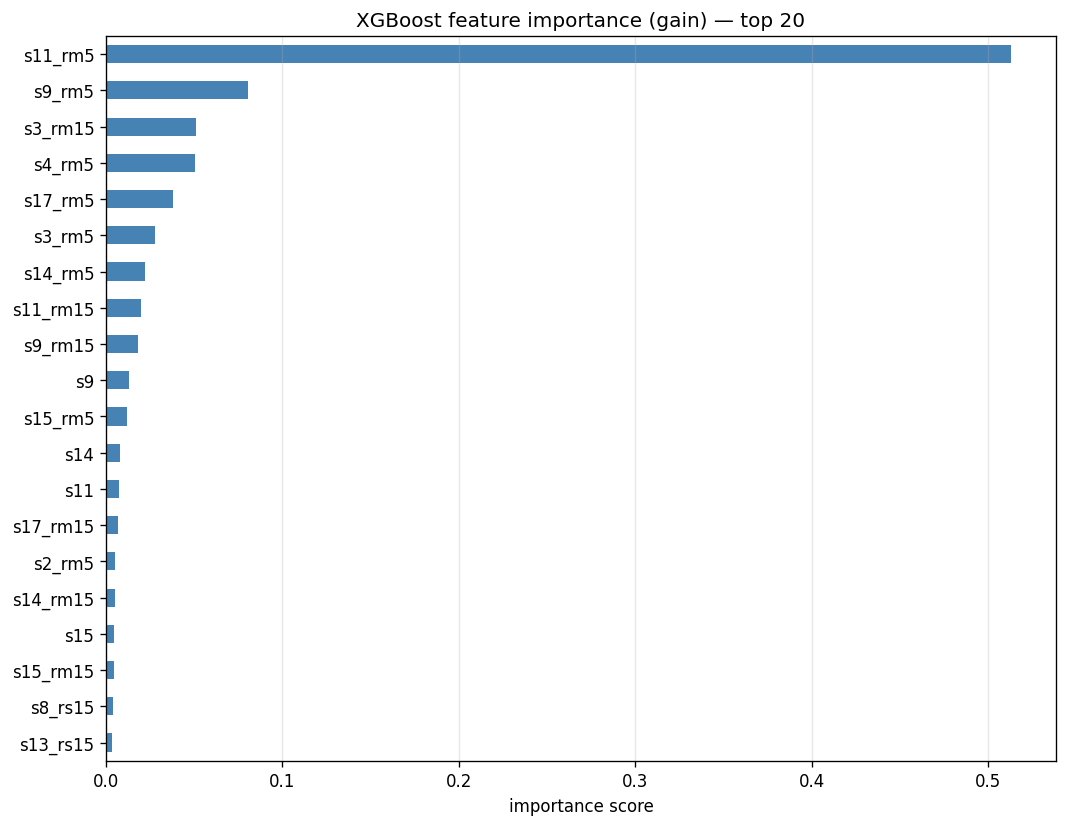

In [100]:
imp = pd.Series(model.feature_importances_, index=FCOLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
imp.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost feature importance (gain) — top 20")
ax.set_xlabel("importance score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

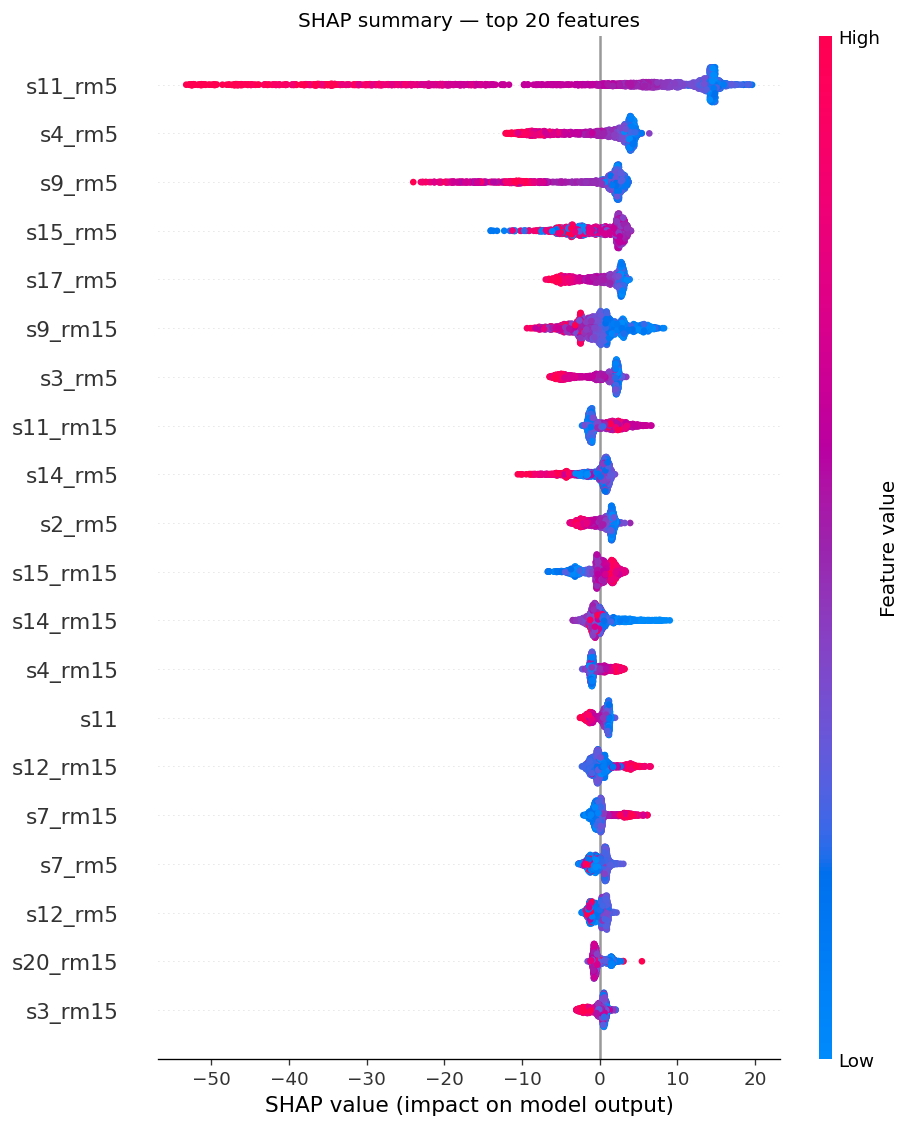

In [101]:
shap_sample = X_va_es.sample(min(2000, len(X_va_es)), random_state=SEED)
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, shap_sample, max_display=20, show=False)
plt.title("SHAP summary — top 20 features")
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()